In [29]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [30]:
tf.random.set_seed(25)
np.random.seed(25)

# Load and prepare data
Only run ONCE

In [31]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# print("Path to dataset files:", path)

In [32]:
# !ls /kaggle/input/plantvillage-dataset/plantvillage\ dataset

In [33]:
# import os
# import shutil

# source_dir = "/content/drive/MyDrive/AI - ShlokDhital/Plant Disease/plantvillage dataset/color"
# target_dir = "/content/drive/MyDrive/AI - ShlokDhital/Plant Disease/filtered_dataset"

# # create target folder
# os.makedirs(target_dir, exist_ok=True)

# selected_prefixes = ["Tomato", "Cherry", "Strawberry"]

# for class_name in os.listdir(source_dir):
#     if any(class_name.startswith(prefix) for prefix in selected_prefixes):
#         src_path = os.path.join(source_dir, class_name)
#         dst_path = os.path.join(target_dir, class_name)

#         print(f"Copying: {class_name}")

#         shutil.copytree(src_path, dst_path, dirs_exist_ok=True)

In [34]:
# import os
# import shutil
# import numpy as np
# from sklearn.model_selection import train_test_split

# src_dir = "/content/drive/MyDrive/AI - ShlokDhital/Plant Disease/filtered_dataset"
# dst_dir = "/content/drive/MyDrive/AI - ShlokDhital/Plant Disease/split_dataset"

# TRAIN_RATIO = 0.7
# VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15
# SEED        = 25

# for class_name in os.listdir(src_dir):
#     class_path = os.path.join(src_dir, class_name)
#     if not os.path.isdir(class_path):
#         continue

#     images = os.listdir(class_path)

#     # Split per class — guarantees balance
#     train_imgs, temp_imgs = train_test_split(images, test_size=(1 - TRAIN_RATIO), random_state=SEED)
#     val_imgs, test_imgs   = train_test_split(temp_imgs, test_size=0.5, random_state=SEED)

#     for split, split_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
#         out_dir = os.path.join(dst_dir, split, class_name)
#         os.makedirs(out_dir, exist_ok=True)
#         for img in split_imgs:
#             shutil.copy(
#                 os.path.join(class_path, img),
#                 os.path.join(out_dir, img)
#             )

#     print(f"{class_name}: {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

## Data Understanding, Analysis, Visualization and Cleaning

In [35]:
# from google.colab import drive
# drive.mount('/content/drive')

In [36]:
import os

def get_class_counts(path):
    class_counts = {}
    total_images = 0

    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
            total_images += count

    return class_counts, total_images

def print_class_table(split_name, class_counts, total_images):

    print(f"\n{split_name.upper()} SET")
    print("=" * 65)
    print(f"{'Class Name':<50}{'Image Count':>15}")
    print("=" * 65)

    for class_name, count in class_counts.items():
        print(f"{class_name:<50}{count:>15}")

    print("=" * 65)
    print(f"{'TOTAL':<50}{total_images:>15}")
    print("=" * 65)

In [37]:
# base_path = "/content/drive/MyDrive/AI - ShlokDhital/Plant Disease/split_dataset"
base_path = "/kaggle/input/datasets/shlokdhital/split-plant-village/split_dataset"

paths = {
    "train": base_path + "/train",
    "val": base_path + "/val",
    "test": base_path + "/test"
}

results = {}

for split, path in paths.items():
    counts, total = get_class_counts(path)
    results[split] = {
        "counts": counts,
        "total": total
    }
    print_class_table(split, counts, total)


TRAIN SET
Class Name                                            Image Count
Tomato___Late_blight                                         1336
Tomato___healthy                                             1113
Tomato___Early_blight                                         699
Tomato___Septoria_leaf_spot                                  1239
Strawberry___Leaf_scorch                                      776
Tomato___Tomato_Yellow_Leaf_Curl_Virus                       3749
Tomato___Bacterial_spot                                      1488
Cherry_(including_sour)___Powdery_mildew                      736
Tomato___Target_Spot                                          982
Tomato___Tomato_mosaic_virus                                  261
Strawberry___healthy                                          319
Cherry_(including_sour)___healthy                             597
Tomato___Leaf_Mold                                            666
Tomato___Spider_mites Two-spotted_spider_mite                1173

In [38]:
train_counts = results["train"]["counts"]
val_counts   = results["val"]["counts"]
test_counts  = results["test"]["counts"]

class_names = list(train_counts.keys())

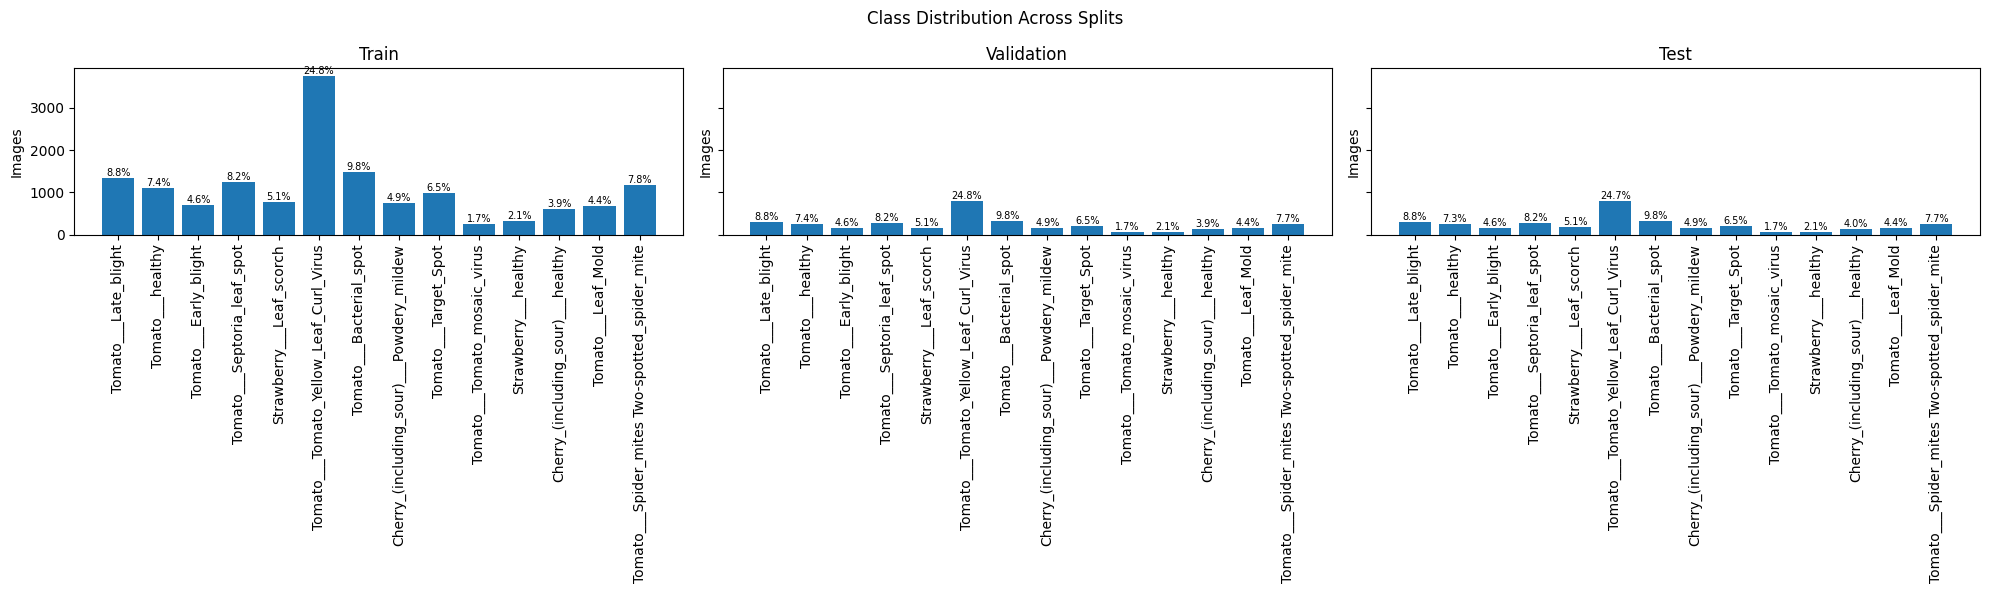

In [39]:
splits = ["Train", "Validation", "Test"]
all_counts = [train_counts, val_counts, test_counts]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, counts, split_name in zip(axes, all_counts, splits):

    class_names = list(counts.keys())
    values = list(counts.values())

    total = sum(values)
    bars = ax.bar(class_names, values)

    ax.set_title(split_name)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel("Images")

    for bar, count in zip(bars, values):
        pct = (count / total) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=7
        )

plt.suptitle("Class Distribution Across Splits")
plt.tight_layout()
plt.show()

In [40]:
import tensorflow as tf

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
SEED = 25

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    paths['train'],
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    paths['val'],
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    paths['test'],
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 15134 files belonging to 14 classes.
Found 3245 files belonging to 14 classes.
Found 3252 files belonging to 14 classes.


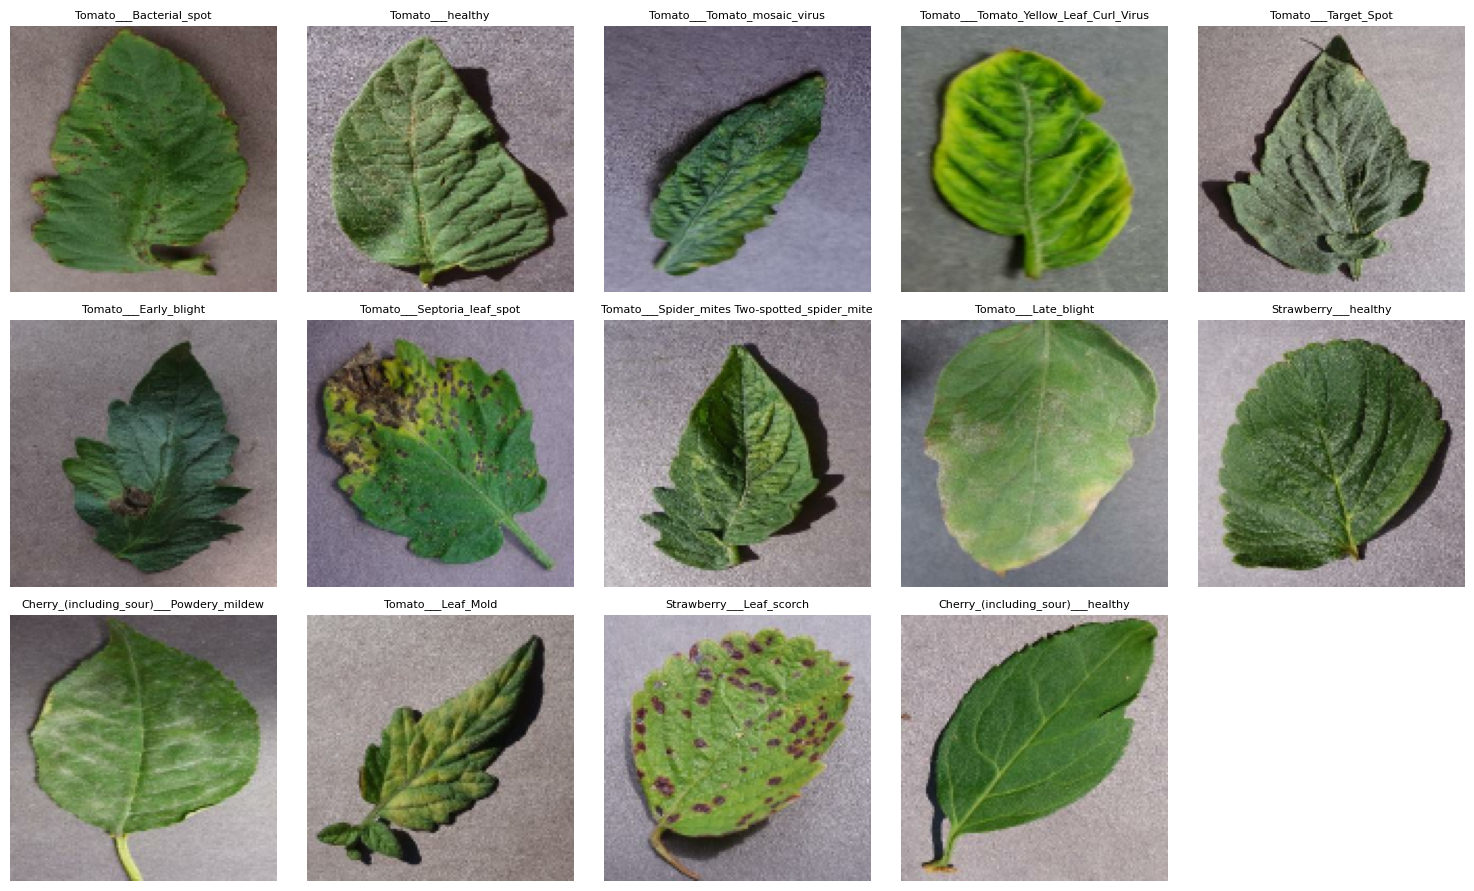

In [41]:
class_images = {}

for images, labels in train_ds.take(50):
    for img, label in zip(images, labels):
        label = int(label.numpy())
        if label not in class_images:
            class_images[label] = img.numpy()

    if len(class_images) == len(train_ds.class_names):
        break

class_names = train_ds.class_names
num_classes = len(class_names)

# dynamic grid size
cols = 5
rows = (num_classes + cols - 1) // cols

plt.figure(figsize=(15, 3 * rows))

for i, (label, img) in enumerate(class_images.items()):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(class_names[label], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
train_counts = np.array([
    len(os.listdir(os.path.join(paths['train'], c)))
    for c in train_ds.class_names
])

total = train_counts.sum()
n_classes = len(train_counts)

class_weights = {i: total / (n_classes * c) for i, c in enumerate(train_counts)}
print(class_weights)

{0: np.float64(1.46875), 1: np.float64(1.8107202680067003), 2: np.float64(1.393041237113402), 3: np.float64(3.3887147335423196), 4: np.float64(0.7264784946236559), 5: np.float64(1.5464949928469243), 6: np.float64(0.8091317365269461), 7: np.float64(1.6231231231231231), 8: np.float64(0.8724778046811945), 9: np.float64(0.9215686274509803), 10: np.float64(1.1008146639511203), 11: np.float64(0.2883435582822086), 12: np.float64(4.14176245210728), 13: np.float64(0.9712488769092543)}


In [43]:
# Prefetch and autotune for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

## Data Augmentation

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=25),
    layers.RandomRotation(0.1, seed=25),
    layers.RandomZoom(0.1, seed=25),
    layers.RandomTranslation(0.1, 0.1, seed=25),
])

In [45]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

img = images[0]

In [46]:
aug_image_count = 7

augmented_images = []

for i in range(aug_image_count):
    augmented = data_augmentation(tf.expand_dims(img, axis=0), training=True)
    augmented_images.append(augmented[0].numpy())

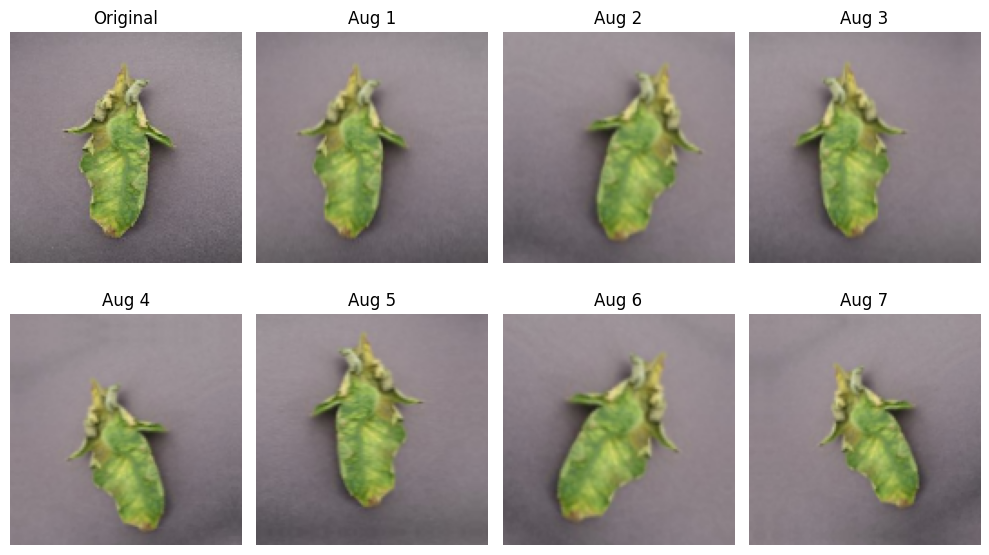

In [47]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 4, 1)
plt.imshow(img.numpy().astype("uint8"))
plt.title("Original")
plt.axis("off")

for i in range(aug_image_count):
    plt.subplot(2, 4, i + 2)
    plt.imshow(augmented_images[i].astype("uint8"))
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Baseline Model

In [48]:
baseline_model = keras.Sequential([

    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(n_classes, activation='softmax')
])

In [49]:
baseline_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,298,478 (16.40 MB)

 Trainable params: 4,298,478 (16.40 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
from tensorflow.keras.optimizers import Adam

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, checkpoint, reduce_lr]

In [52]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1645 - loss: 2.4518
Epoch 1: val_accuracy improved from -inf to 0.62619, saving model to best_model.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.1648 - loss: 2.4509 - val_accuracy: 0.6262 - val_loss: 1.1297 - learning_rate: 0.0010
Epoch 2/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6367 - loss: 1.1122
Epoch 2: val_accuracy improved from 0.62619 to 0.74730, saving model to best_model.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6369 - loss: 1.1116 - val_accuracy: 0.7473 - val_loss: 0.7389 - learning_rate: 0.0010
Epoch 3/20
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7503 - loss: 0.7451
Epoch 3: val_accuracy did not improve from 0.74730
473/473 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7504 - loss: 0.7446 - val_accuracy: 0.7418 - val_loss: 0.7502 - learning_rate: 0.0010
Epoch 4/20
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8256 - loss: 0.51

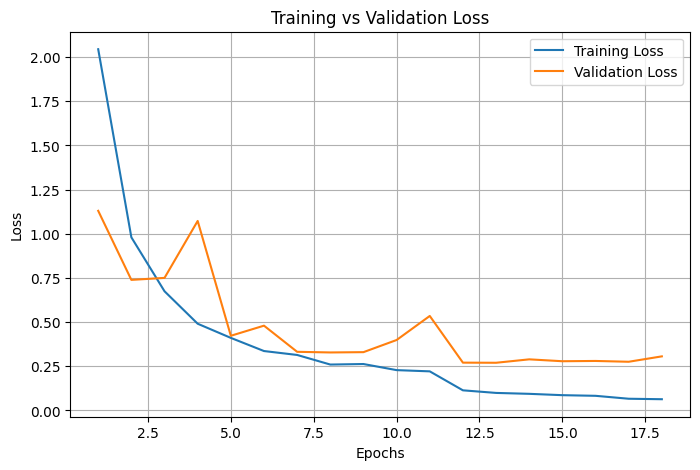

In [53]:
train_loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.grid(True)
plt.show()

In [148]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Predictions
y_pred_probs = baseline_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = np.mean(y_true == y_pred)
print("Test Accuracy:", accuracy)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Test Accuracy: 0.9191266912669127



Classification Report:
                                               precision    recall  f1-score   support

     Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       158
            Cherry_(including_sour)___healthy       1.00      0.98      0.99       129
                     Strawberry___Leaf_scorch       0.99      0.95      0.97       167
                         Strawberry___healthy       0.97      1.00      0.99        69
                      Tomato___Bacterial_spot       0.97      0.81      0.88       320
                        Tomato___Early_blight       0.59      0.85      0.70       151
                         Tomato___Late_blight       0.91      0.91      0.91       287
                           Tomato___Leaf_Mold       0.96      0.87      0.92       143
                  Tomato___Septoria_leaf_spot       0.91      0.92      0.92       266
Tomato___Spider_mites Two-spotted_spider_mite       0.82      0.94      0.88       252
                  

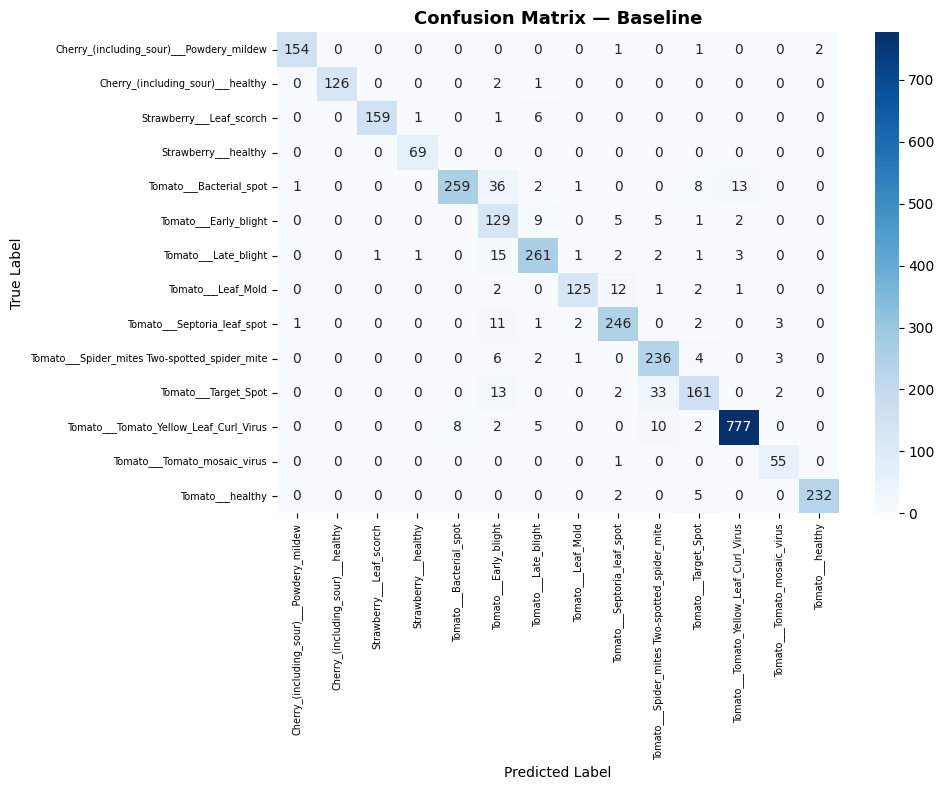

In [149]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm_baseline = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.set_title('Confusion Matrix — Baseline', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, rotation=0, fontsize=7)

plt.tight_layout()
plt.show()

In [55]:
print(cm)

[[154   0   0   0   0   0   0   0   1   0   1   0   0   2]
 [  0 126   0   0   0   2   1   0   0   0   0   0   0   0]
 [  0   0 159   1   0   1   6   0   0   0   0   0   0   0]
 [  0   0   0  69   0   0   0   0   0   0   0   0   0   0]
 [  1   0   0   0 259  36   2   1   0   0   8  13   0   0]
 [  0   0   0   0   0 129   9   0   5   5   1   2   0   0]
 [  0   0   1   1   0  15 261   1   2   2   1   3   0   0]
 [  0   0   0   0   0   2   0 125  12   1   2   1   0   0]
 [  1   0   0   0   0  11   1   2 246   0   2   0   3   0]
 [  0   0   0   0   0   6   2   1   0 236   4   0   3   0]
 [  0   0   0   0   0  13   0   0   2  33 161   0   2   0]
 [  0   0   0   0   8   2   5   0   0  10   2 777   0   0]
 [  0   0   0   0   0   0   0   0   1   0   0   0  55   0]
 [  0   0   0   0   0   0   0   0   2   0   5   0   0 232]]


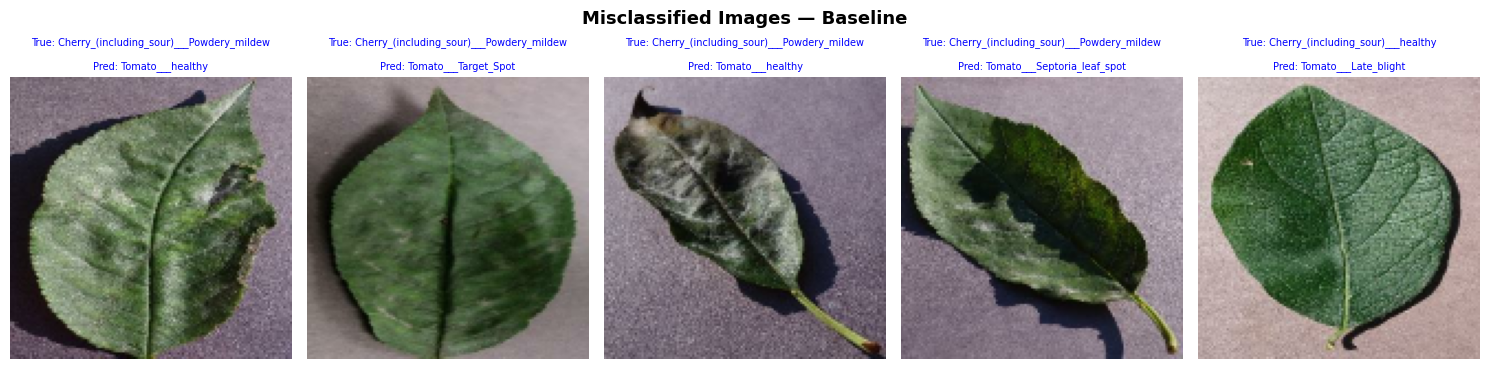

In [152]:
images_all = np.concatenate([x for x, y in test_ds], axis=0)

misclassified_idx = np.where(y_true != y_pred)[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(misclassified_idx[:5]):
    img = images_all[idx].astype('uint8')
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {class_names[y_true[idx]]}\n\nPred: {class_names[y_pred[idx]]}',
        fontsize=7,
        color='blue'
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Images — Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
baseline_model.save("model_baseline.keras")

# Deeper Model

In [60]:
from tensorflow.keras import layers, regularizers, Sequential

def build_deeper_model():
  weight_decay = 1e-4
  model = Sequential([

    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    normalization_layer,

    # 3x3 conv 32
    layers.Conv2D(32, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
    # 3x3 conv 32
    layers.Conv2D(32, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
      
    # half pooling
    layers.MaxPooling2D(),


    # 3x3 conv 64
    layers.Conv2D(64, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
    # 3x3 conv 64
    layers.Conv2D(64, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
      
    # half pooling
    layers.MaxPooling2D(),


    # 3x3 conv 128
    layers.Conv2D(128, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
    # 3x3 conv 128
    layers.Conv2D(128, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
    # 3x3 conv 128
    layers.Conv2D(128, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),

    # half pooling
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(128, kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.4),

    layers.Dense(64, kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),

    layers.Dense(n_classes, activation='softmax')
  ])
  return model

deeper_model = build_deeper_model()
deeper_model.save_weights("initial.weights.h5")

In [61]:
deeper_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_50 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_51 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_52 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_53 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_54 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_55 (ReLU)                 │ (None, 32, 32, 128)    │             

 Total params: 8,869,614 (33.83 MB)

 Trainable params: 8,867,566 (33.83 MB)

 Non-trainable params: 2,048 (8.00 KB)

## Adam

In [62]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_deeper_model_adam.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_adam = [early_stopping, checkpoint, reduce_lr]

In [63]:
from tensorflow.keras.optimizers import Adam

model_adam = build_deeper_model()
model_adam.load_weights("initial.weights.h5")

model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_adam
)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3146 - loss: 2.3234
Epoch 1: val_accuracy improved from -inf to 0.24284, saving model to best_deeper_model_adam.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - accuracy: 0.3149 - loss: 2.3225 - val_accuracy: 0.2428 - val_loss: 3.8287 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6310 - loss: 1.3210
Epoch 2: val_accuracy improved from 0.24284 to 0.52388, saving model to best_deeper_model_adam.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 51s 107ms/step - accuracy: 0.6310 - loss: 1.3209 - val_accuracy: 0.5239 - val_loss: 1.7567 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7049 - loss: 1.0918
Epoch 3: val_accuracy improved from 0.52388 to 0.59599, saving model to best_deeper_model_adam.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.7049 - loss: 1.0917 - val_accuracy: 0.5960 - val_loss: 1.7099 - learning_rate: 0.0010
Epoc

In [64]:
model_adam.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_60 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_61 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_62 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_63 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_64 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_65 (ReLU)                 │ (None, 32, 32, 128)    │             

 Total params: 26,604,748 (101.49 MB)

 Trainable params: 8,867,566 (33.83 MB)

 Non-trainable params: 2,048 (8.00 KB)

 Optimizer params: 17,735,134 (67.65 MB)

In [65]:
model_adam.save("model_adam.keras")

## SGD

In [66]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_deeper_model_sgd.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_sgd = [early_stopping, checkpoint, reduce_lr]

In [68]:
model_sgd = build_deeper_model()
model_sgd.load_weights("/kaggle/working/initial.weights.h5")

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_sgd
)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2172 - loss: 2.5987
Epoch 1: val_accuracy did not improve from 0.86564
473/473 ━━━━━━━━━━━━━━━━━━━━ 54s 103ms/step - accuracy: 0.2175 - loss: 2.5979 - val_accuracy: 0.2388 - val_loss: 2.6188 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5417 - loss: 1.5870
Epoch 2: val_accuracy did not improve from 0.86564
473/473 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.5418 - loss: 1.5867 - val_accuracy: 0.4240 - val_loss: 2.0154 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6288 - loss: 1.2766
Epoch 3: val_accuracy did not improve from 0.86564
473/473 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.6288 - loss: 1.2764 - val_accuracy: 0.5787 - val_loss: 1.4450 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7111 - loss: 1.0406
Epoch 4: val_accuracy did not improve from 0.86564
473/473 ━━━━━━━━

In [69]:
model_sgd.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_80 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_81 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_82 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_83 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_84 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_85 (ReLU)                 │ (None, 32, 32, 128)    │             

 Total params: 17,737,182 (67.66 MB)

 Trainable params: 8,867,566 (33.83 MB)

 Non-trainable params: 2,048 (8.00 KB)

 Optimizer params: 8,867,568 (33.83 MB)

In [70]:
model_sgd.save("model_sgd.keras")

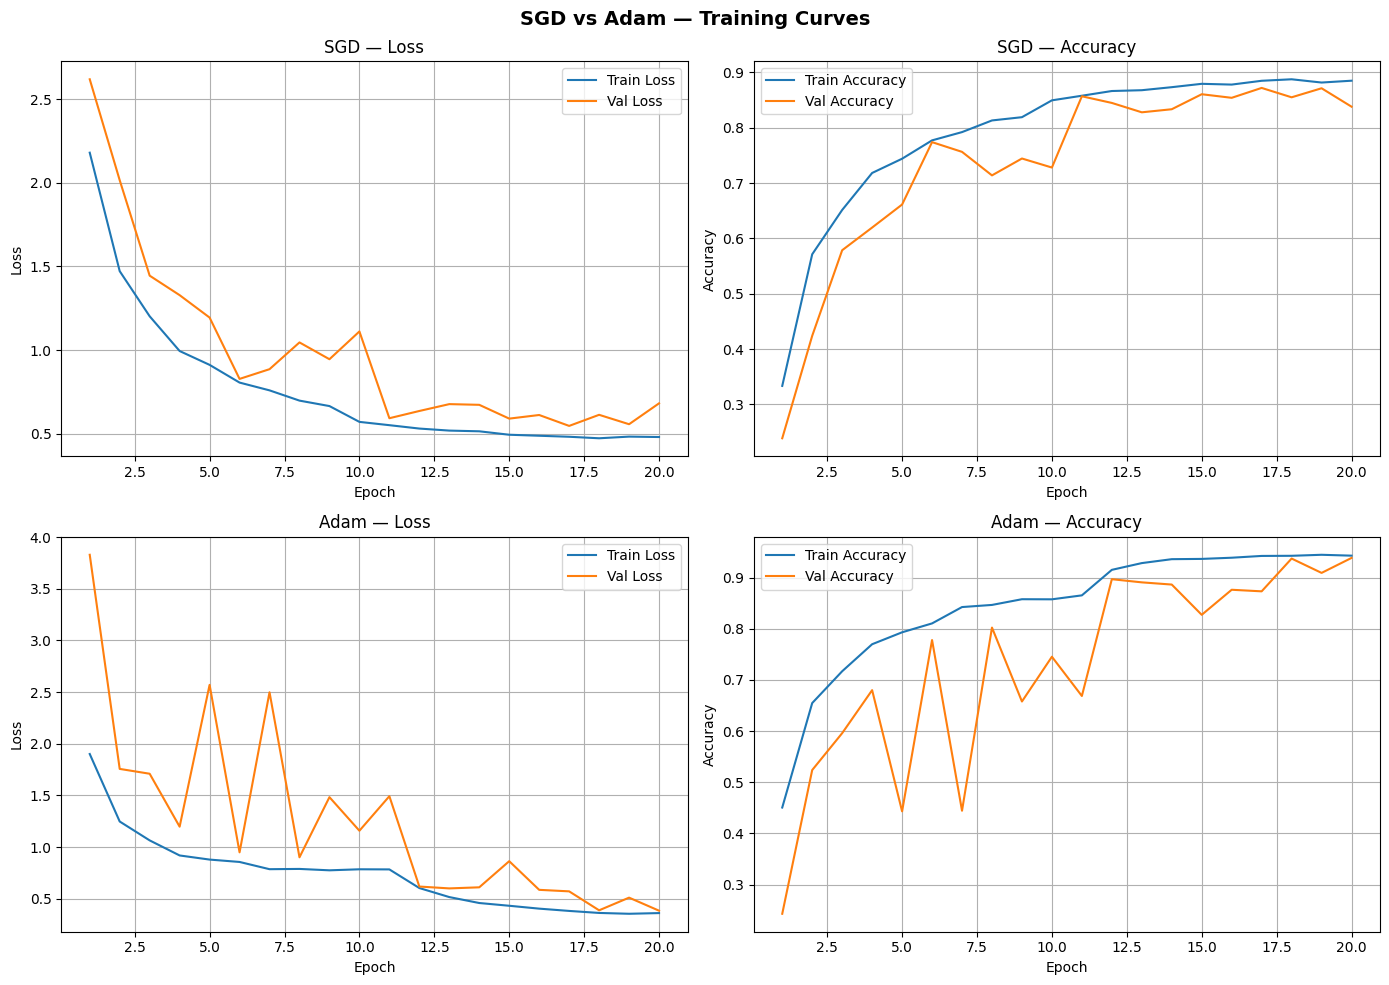

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_sgd = range(1, len(history_sgd.history['loss']) + 1)
axes[0, 0].plot(epochs_sgd, history_sgd.history['loss'],     label='Train Loss')
axes[0, 0].plot(epochs_sgd, history_sgd.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('SGD — Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_sgd, history_sgd.history['accuracy'],     label='Train Accuracy')
axes[0, 1].plot(epochs_sgd, history_sgd.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('SGD — Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

epochs_adam = range(1, len(history_adam.history['loss']) + 1)
axes[1, 0].plot(epochs_adam, history_adam.history['loss'],     label='Train Loss')
axes[1, 0].plot(epochs_adam, history_adam.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('Adam — Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_adam, history_adam.history['accuracy'],     label='Train Accuracy')
axes[1, 1].plot(epochs_adam, history_adam.history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('Adam — Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

fig.suptitle('SGD vs Adam — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [153]:
y_pred_sgd  = np.argmax(model_sgd.predict(test_ds),  axis=1)
y_pred_adam = np.argmax(model_adam.predict(test_ds), axis=1)

print(f"SGD  Test Accuracy: {np.mean(y_true == y_pred_sgd):.4f}")
print(f"Adam Test Accuracy: {np.mean(y_true == y_pred_adam):.4f}")

102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
SGD  Test Accuracy: 0.8859
Adam Test Accuracy: 0.9379



Classification Report — SGD:
                                               precision    recall  f1-score   support

     Cherry_(including_sour)___Powdery_mildew       0.98      0.94      0.96       158
            Cherry_(including_sour)___healthy       1.00      0.95      0.98       129
                     Strawberry___Leaf_scorch       1.00      0.99      0.99       167
                         Strawberry___healthy       0.96      1.00      0.98        69
                      Tomato___Bacterial_spot       0.97      0.78      0.86       320
                        Tomato___Early_blight       0.57      0.96      0.71       151
                         Tomato___Late_blight       1.00      0.82      0.90       287
                           Tomato___Leaf_Mold       0.96      0.92      0.94       143
                  Tomato___Septoria_leaf_spot       0.97      0.87      0.92       266
Tomato___Spider_mites Two-spotted_spider_mite       0.83      0.65      0.73       252
            

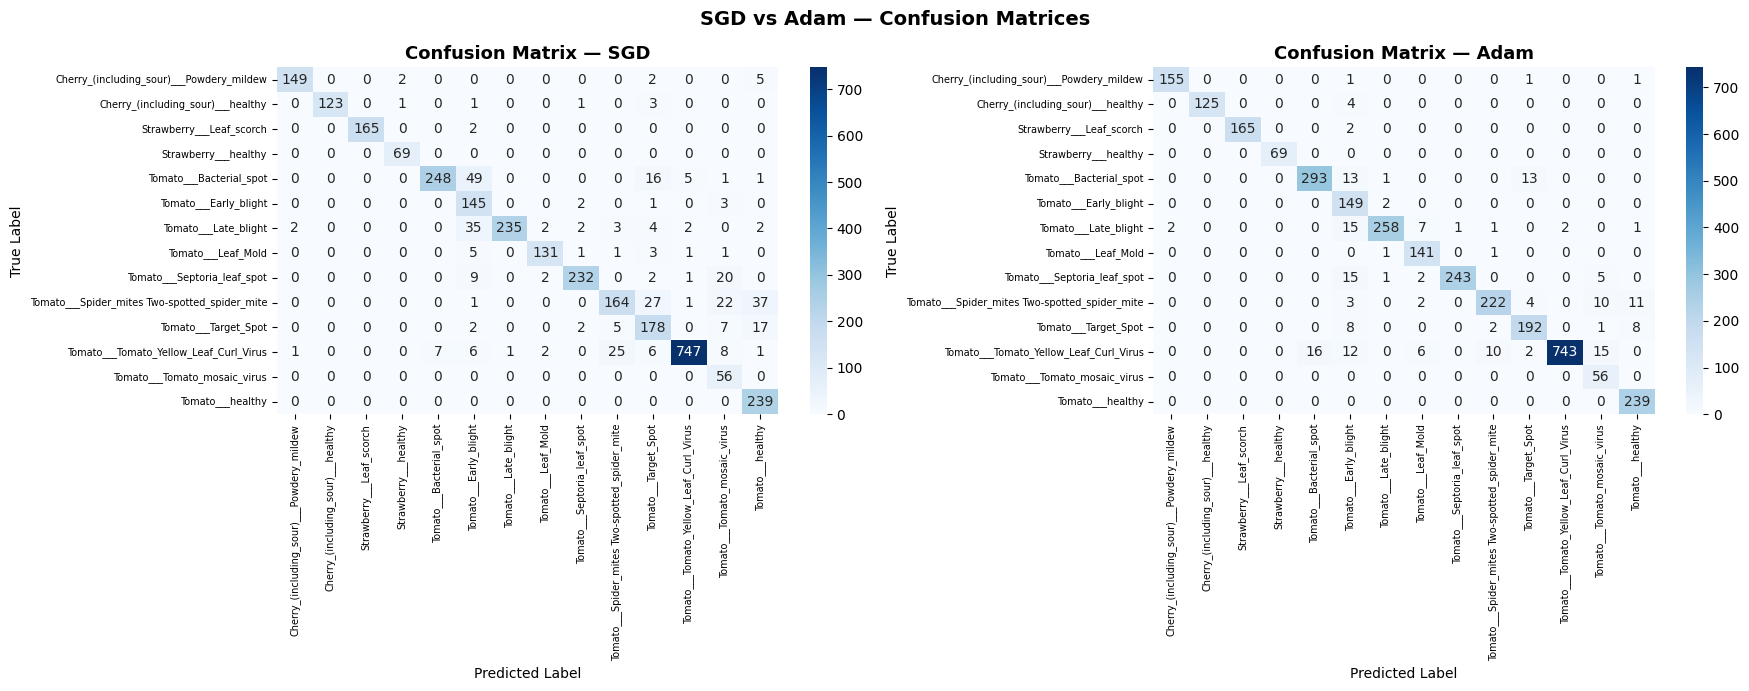

In [92]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report — SGD:")
print(classification_report(y_true, y_pred_sgd, target_names=class_names))

print("\nClassification Report — Adam:")
print(classification_report(y_true, y_pred_adam, target_names=class_names))

cm_sgd  = confusion_matrix(y_true, y_pred_sgd)
cm_adam = confusion_matrix(y_true, y_pred_adam)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cm, title in zip(axes, [cm_sgd, cm_adam], ['SGD', 'Adam']):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(class_names, rotation=90, fontsize=7)
    ax.set_yticklabels(class_names, rotation=0, fontsize=7)

plt.suptitle('SGD vs Adam — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [73]:
print(cm_adam)
print("-"*20)
print(cm_sgd)

[[155   0   0   0   0   1   0   0   0   0   1   0   0   1]
 [  0 125   0   0   0   4   0   0   0   0   0   0   0   0]
 [  0   0 165   0   0   2   0   0   0   0   0   0   0   0]
 [  0   0   0  69   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 293  13   1   0   0   0  13   0   0   0]
 [  0   0   0   0   0 149   2   0   0   0   0   0   0   0]
 [  2   0   0   0   0  15 258   7   1   1   0   2   0   1]
 [  0   0   0   0   0   0   1 141   0   1   0   0   0   0]
 [  0   0   0   0   0  15   1   2 243   0   0   0   5   0]
 [  0   0   0   0   0   3   0   2   0 222   4   0  10  11]
 [  0   0   0   0   0   8   0   0   0   2 192   0   1   8]
 [  0   0   0   0  16  12   0   6   0  10   2 743  15   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  56   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 239]]
--------------------
[[149   0   0   2   0   0   0   0   0   0   2   0   0   5]
 [  0 123   0   1   0   1   0   0   1   0   3   0   0   0]
 [  0   0 165   0   0   2   0   0 

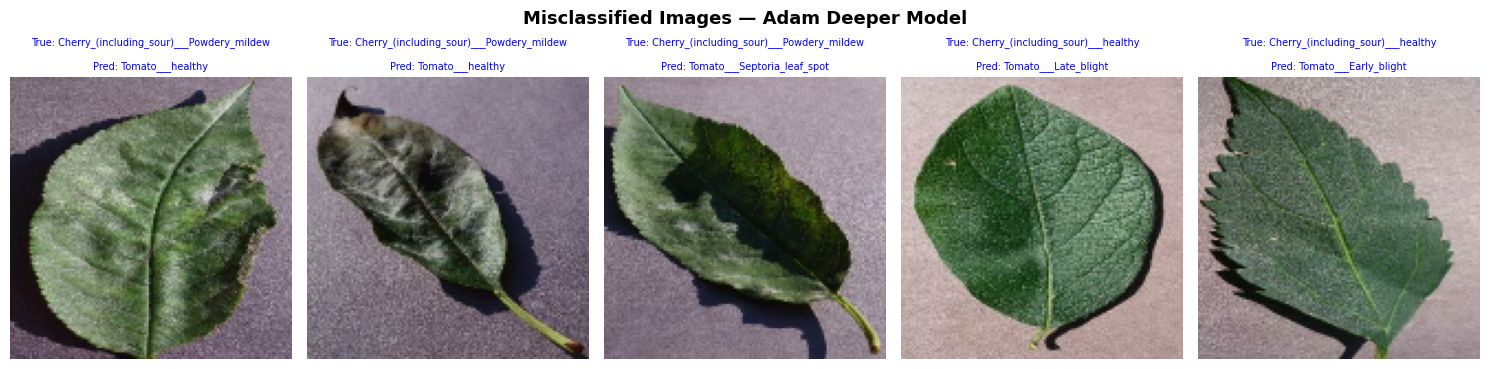

In [154]:
images_all = np.concatenate([x for x, y in test_ds], axis=0)

misclassified_idx = np.where(y_true != y_pred_adam)[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(misclassified_idx[:5]):
    img = images_all[idx].astype('uint8')
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {class_names[y_true[idx]]}\n\nPred: {class_names[y_pred[idx]]}',
        fontsize=7,
        color='blue'
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Images — Adam Deeper Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

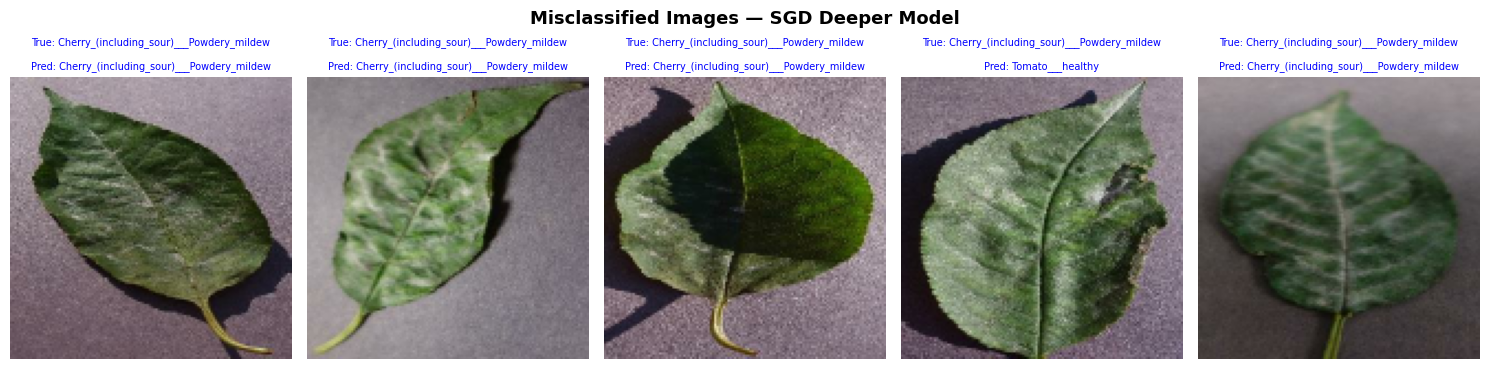

In [155]:
images_all = np.concatenate([x for x, y in test_ds], axis=0)

misclassified_idx = np.where(y_true != y_pred_sgd)[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(misclassified_idx[:5]):
    img = images_all[idx].astype('uint8')
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {class_names[y_true[idx]]}\n\nPred: {class_names[y_pred[idx]]}',
        fontsize=7,
        color='blue'
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Images — SGD Deeper Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ablation Test Model

In [74]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_deeper_model_no_dropout.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_no_dropout = [early_stopping, checkpoint, reduce_lr]

In [75]:
def build_deeper_model_no_dropout():
  weight_decay = 1e-4
  model = Sequential([
      layers.Input(shape=(128, 128, 3)),

      data_augmentation,
      normalization_layer,

      layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      layers.MaxPooling2D(),

      layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      layers.MaxPooling2D(),

      layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      layers.MaxPooling2D(),

      layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      layers.MaxPooling2D(),

      layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      layers.MaxPooling2D(),

      layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      layers.MaxPooling2D(),

      layers.Flatten(),

      layers.Dense(256, kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      # Dropout(0.5) # removed

      layers.Dense(128, kernel_regularizer=regularizers.l2(weight_decay)),
      layers.BatchNormalization(),
      layers.ReLU(),
      # Dropout(0.4) # removed

      layers.Dense(n_classes, activation='softmax')
    ])
  return model

In [77]:
model_no_dropout = build_deeper_model_no_dropout()

model_no_dropout.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_no_dropout = model_no_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_no_dropout
)

Epoch 1/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5798 - loss: 1.3587
Epoch 1: val_accuracy improved from 0.37720 to 0.39260, saving model to best_deeper_model_no_dropout.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5803 - loss: 1.3570 - val_accuracy: 0.3926 - val_loss: 2.3528 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8339 - loss: 0.5646
Epoch 2: val_accuracy improved from 0.39260 to 0.57658, saving model to best_deeper_model_no_dropout.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8339 - loss: 0.5646 - val_accuracy: 0.5766 - val_loss: 1.5964 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8773 - loss: 0.4307
Epoch 3: val_accuracy improved from 0.57658 to 0.66749, saving model to best_deeper_model_no_dropout.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8773 - loss: 0.4307 - val_accuracy: 0.6675 - val_loss: 1.2073 - learning_ra

In [78]:
model_no_dropout.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_98          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_98 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_99 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_100 (ReLU)                │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_101 (ReLU)                │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_102 (ReLU)                │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,365,772 (5.21 MB)

 Trainable params: 454,702 (1.73 MB)

 Non-trainable params: 1,664 (6.50 KB)

 Optimizer params: 909,406 (3.47 MB)

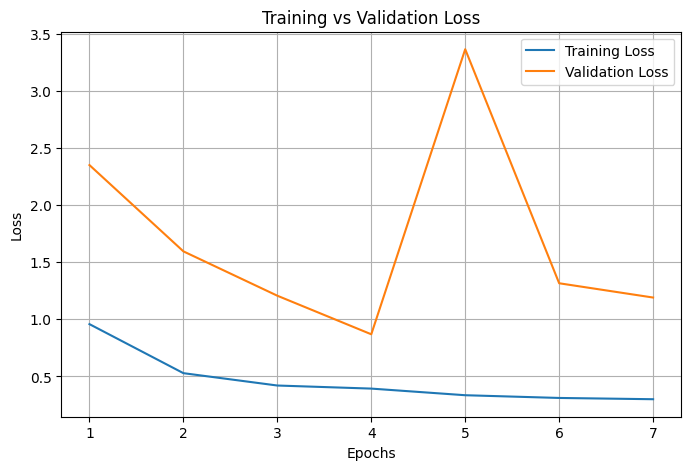

In [80]:
train_loss = history_no_dropout.history['loss']
val_loss = history_no_dropout.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.grid(True)
plt.show()

In [156]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Get true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Predictions
y_pred_probs = model_no_dropout.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = np.mean(y_true == y_pred)
print("Test Accuracy:", accuracy)

102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Test Accuracy: 0.754920049200492



Classification Report:
                                               precision    recall  f1-score   support

     Cherry_(including_sour)___Powdery_mildew       0.83      0.97      0.90       158
            Cherry_(including_sour)___healthy       0.87      1.00      0.93       129
                     Strawberry___Leaf_scorch       1.00      0.49      0.66       167
                         Strawberry___healthy       0.78      1.00      0.88        69
                      Tomato___Bacterial_spot       1.00      0.69      0.81       320
                        Tomato___Early_blight       0.30      0.92      0.45       151
                         Tomato___Late_blight       0.83      0.76      0.79       287
                           Tomato___Leaf_Mold       0.73      0.85      0.78       143
                  Tomato___Septoria_leaf_spot       0.83      0.63      0.71       266
Tomato___Spider_mites Two-spotted_spider_mite       0.81      0.69      0.75       252
                  

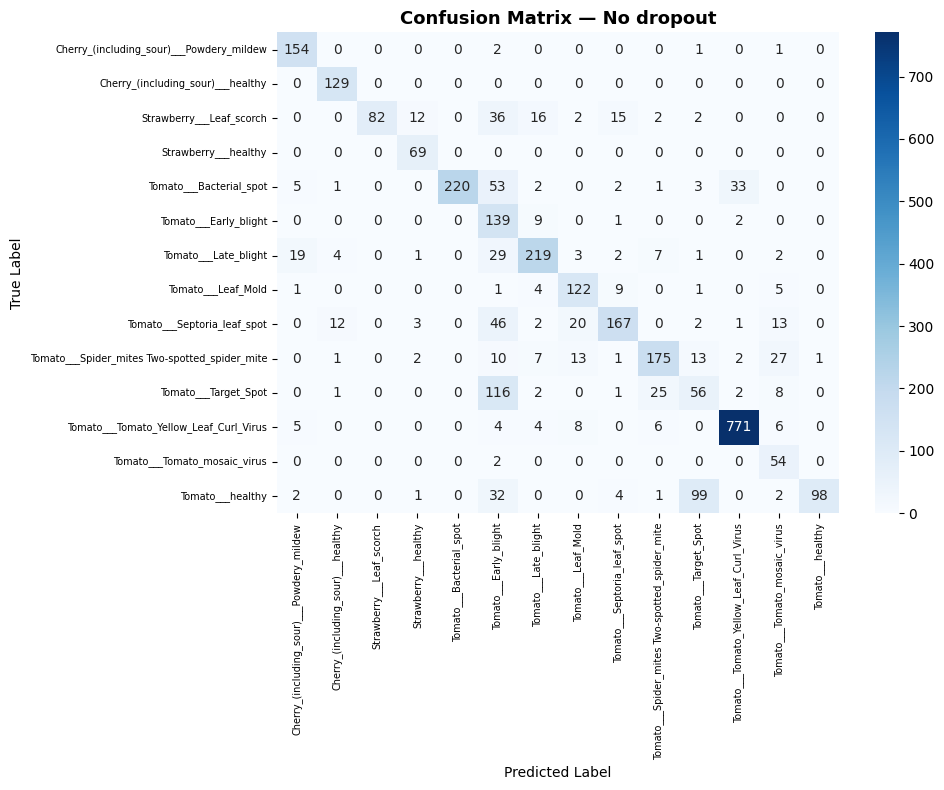

In [93]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm_no_dropout = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm_no_dropout, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax)

ax.set_title('Confusion Matrix — No dropout', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)

plt.tight_layout()
plt.show()

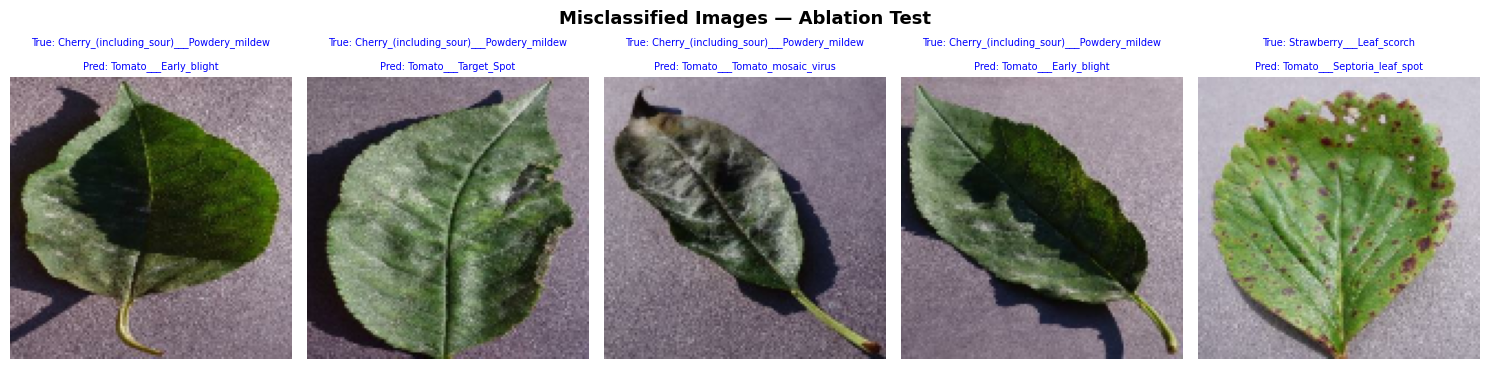

In [157]:
images_all = np.concatenate([x for x, y in test_ds], axis=0)

misclassified_idx = np.where(y_true != y_pred)[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(misclassified_idx[:5]):
    img = images_all[idx].astype('uint8')
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {class_names[y_true[idx]]}\n\nPred: {class_names[y_pred[idx]]}',
        fontsize=7,
        color='blue'
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Images — Ablation Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [79]:
model_no_dropout.save("model_no_dropout.keras")

# Transfer Learning

In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, regularizers, Sequential

base_model = VGG16(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model_vgg = Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    
    layers.Lambda(preprocess_input, name='vgg_preprocessing'),
    
    base_model,
    
    layers.Flatten(),
    
    layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.5),
    
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.4),
    
    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),
    
    layers.Dense(n_classes, activation='softmax')
])

In [132]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_vgg.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_vgg = [early_stopping, checkpoint, reduce_lr]

In [133]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_vgg
)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3350 - loss: 2.0998
Epoch 1: val_accuracy improved from -inf to 0.73467, saving model to best_vgg.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - accuracy: 0.3353 - loss: 2.0988 - val_accuracy: 0.7347 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7017 - loss: 1.0519
Epoch 2: val_accuracy improved from 0.73467 to 0.82989, saving model to best_vgg.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.7017 - loss: 1.0518 - val_accuracy: 0.8299 - val_loss: 0.6519 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7560 - loss: 0.8914
Epoch 3: val_accuracy improved from 0.82989 to 0.86471, saving model to best_vgg.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.7560 - loss: 0.8914 - val_accuracy: 0.8647 - val_loss: 0.5853 - learning_rate: 0.0010
Epoch 4/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

In [134]:
model_vgg.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_preprocessing (Lambda)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_127         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_127 (ReLU)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_128         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_128 (ReLU)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_129         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_129 (ReLU)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,136,684 (80.63 MB)

 Trainable params: 2,140,366 (8.16 MB)

 Non-trainable params: 14,715,584 (56.14 MB)

 Optimizer params: 4,280,734 (16.33 MB)

In [7]:
from tensorflow.keras.optimizers import Adam

base_model.trainable = True

for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    print(layer.name, layer.trainable)

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

input_layer_5 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [8]:
model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_preprocessing (Lambda)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,855,950 (64.30 MB)

 Trainable params: 9,219,790 (35.17 MB)

 Non-trainable params: 7,636,160 (29.13 MB)

In [137]:
# Continue training
history_vgg_finetune = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_vgg_finetuned.keras',
            monitor='val_accuracy',
            save_best_only=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.2,
            patience=2,
            min_lr=1e-7
        )
    ]
)

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.8986 - loss: 0.4786 - val_accuracy: 0.9322 - val_loss: 0.4089 - learning_rate: 1.0000e-05
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.9206 - loss: 0.4240 - val_accuracy: 0.9331 - val_loss: 0.3919 - learning_rate: 1.0000e-05
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.9262 - loss: 0.4061 - val_accuracy: 0.9411 - val_loss: 0.3651 - learning_rate: 1.0000e-05
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9379 - loss: 0.3798 - val_accuracy: 0.9492 - val_loss: 0.3505 - learning_rate: 1.0000e-05
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - accuracy: 0.9367 - loss: 0.3766 - val_accuracy: 0.9492 - val_loss: 0.3428 - learning_rate: 1.0000e-05
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 34s 71ms/step - accuracy: 0.9462 - loss: 0.3503 - val_accuracy: 0.9516 - val_loss: 0.3374 - learning_rate: 1.0000e-05
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/ste

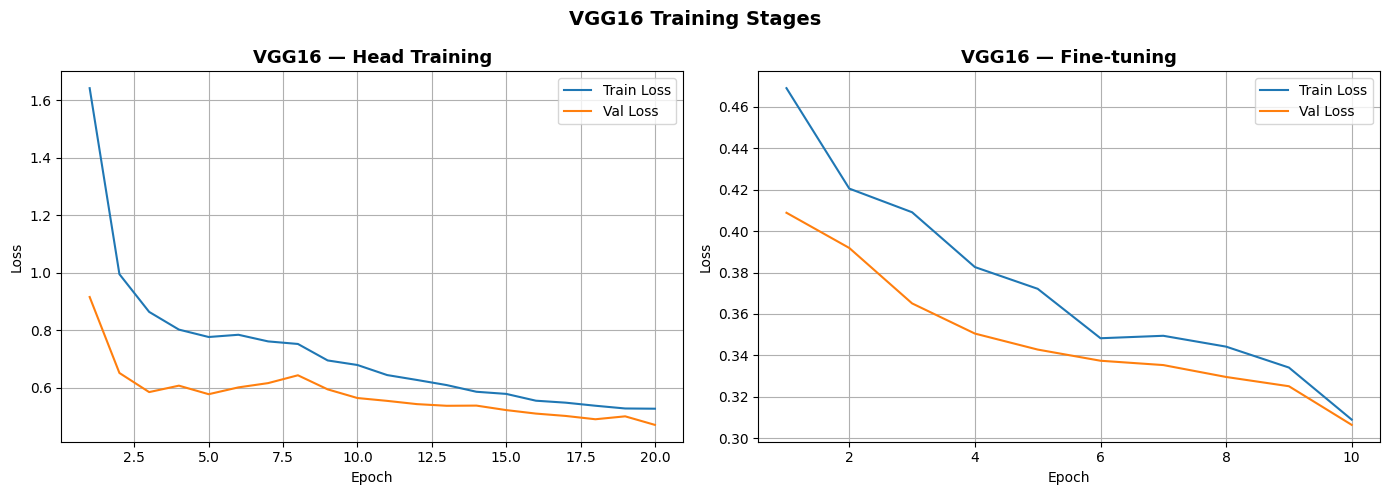

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_vgg = range(1, len(history_vgg.history['loss']) + 1)
axes[0].plot(epochs_vgg, history_vgg.history['loss'],         label='Train Loss')
axes[0].plot(epochs_vgg, history_vgg.history['val_loss'],     label='Val Loss')
axes[0].set_title('VGG16 — Head Training', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

epochs_ft = range(1, len(history_vgg_finetune.history['loss']) + 1)
axes[1].plot(epochs_ft, history_vgg_finetune.history['loss'],     label='Train Loss')
axes[1].plot(epochs_ft, history_vgg_finetune.history['val_loss'], label='Val Loss')
axes[1].set_title('VGG16 — Fine-tuning', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('VGG16 Training Stages', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [158]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Get true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Predictions
y_pred_probs = model_vgg.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = np.mean(y_true == y_pred)
print("Test Accuracy:", accuracy)

102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
Test Accuracy: 0.956949569495695



Classification Report:
                                               precision    recall  f1-score   support

     Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       158
            Cherry_(including_sour)___healthy       1.00      1.00      1.00       129
                     Strawberry___Leaf_scorch       1.00      0.99      1.00       167
                         Strawberry___healthy       1.00      1.00      1.00        69
                      Tomato___Bacterial_spot       0.93      0.98      0.95       320
                        Tomato___Early_blight       0.95      0.81      0.88       151
                         Tomato___Late_blight       0.95      0.98      0.97       287
                           Tomato___Leaf_Mold       1.00      0.87      0.93       143
                  Tomato___Septoria_leaf_spot       0.88      0.98      0.93       266
Tomato___Spider_mites Two-spotted_spider_mite       0.89      0.94      0.92       252
                  

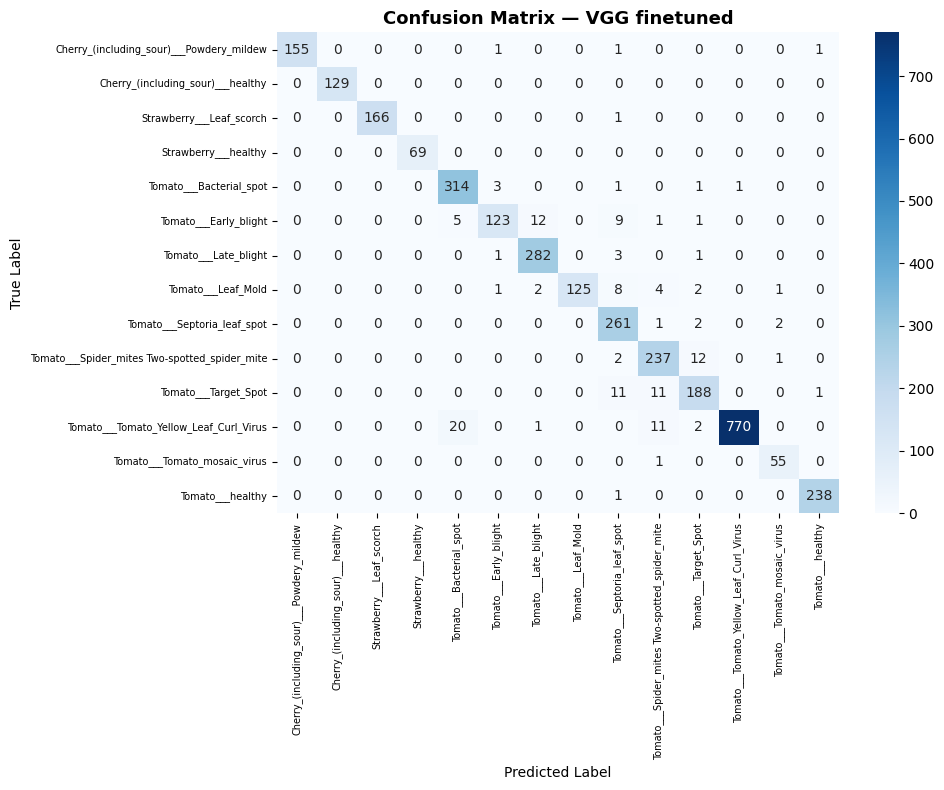

In [140]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm_vgg_finetuned = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm_vgg_finetuned, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax)

ax.set_title('Confusion Matrix — VGG finetuned', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)

plt.tight_layout()
plt.show()

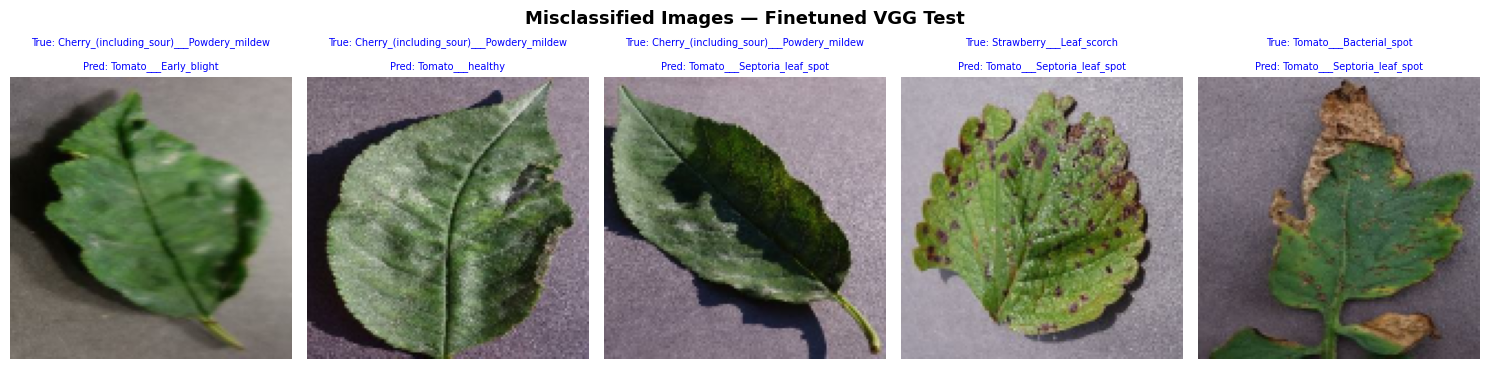

In [159]:
images_all = np.concatenate([x for x, y in test_ds], axis=0)

misclassified_idx = np.where(y_true != y_pred)[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(misclassified_idx[:5]):
    img = images_all[idx].astype('uint8')
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {class_names[y_true[idx]]}\n\nPred: {class_names[y_pred[idx]]}',
        fontsize=7,
        color='blue'
    )
    axes[i].axis('off')

plt.suptitle('Misclassified Images — Finetuned VGG Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [141]:
model_vgg.save('model_vgg.keras')